In [1]:
import os, sys, copy, pickle
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt

sys.path.append("../src")

from iful.image_set import *
from iful.util import *

In [2]:
datacube_filename = "example_data/carousel_lens_muse_trunc.fits"
ifu_psf_filename = "example_data/final_psf.npy"

full_datacube = fits.getdata(datacube_filename, 1)

header = fits.getheader(datacube_filename, 1)
full_datacube = np.transpose(
    full_datacube, (1, 2, 0)
)  
full_datacube.shape

pixscale = (header["CD1_2"] ** 2 + header["CD1_1"] ** 2) ** 0.5
wavelengths = header["CRVAL3"] + header["CD3_3"] * (1 + np.arange(header["NAXIS3"]))
delta_wave = wavelengths[1] - wavelengths[0]

zl = 0.49
exptime = fits.getheader(datacube_filename, 0)["EXPTIME"]
size = 200

x_bounds = (100 - size // 2, 100 + size // 2)
y_bounds = (100 - size // 2, 100 + size // 2)

full_datacube = full_datacube[x_bounds[0] : x_bounds[1], y_bounds[0] : y_bounds[1], :]

/tmp/ipykernel_2111954/1882527526.py:6: RuntimeWarning: invalid value encountered in log10
  plt.imshow(np.log10(np.rot90(full_datacube_whitelight.T, 3)))


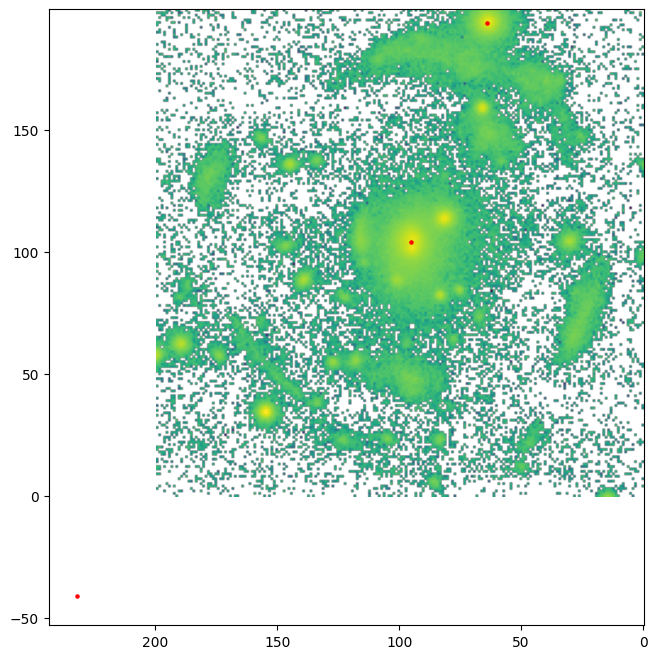

In [3]:
# locations based on brightest pixel location
init_lens_center = np.array([(104, 104), (194, 135), (-41, -33)])

plt.figure(figsize=(8, 8))
full_datacube_whitelight = np.nanmedian(full_datacube, axis=2)
plt.imshow(np.log10(np.rot90(full_datacube_whitelight.T, 3)))

init_lens_center_plt = np.array(
    [
        [
            -(j - (size / 2 - 0.5)) + (size / 2 - 0.5),
            (i - (size / 2 - 0.5)) + (size / 2 - 0.5),
        ]
        for i, j in init_lens_center
    ]
) 
plt.scatter(init_lens_center_plt.T[0], init_lens_center_plt.T[1], c="r", s=5)

plt.gca().invert_yaxis()
plt.gca().invert_xaxis()
plt.show()

In [4]:
header_wcs = copy.deepcopy(header)
header_wcs["CRPIX1"] = init_lens_center[0, 0] + 1
header_wcs["CRVAL1"] = 0.0
header_wcs["NAXIS1"] = full_datacube_whitelight.shape[0]

header_wcs["CRPIX2"] = init_lens_center[0, 1] + 1
header_wcs["CRVAL2"] = 0.0
header_wcs["NAXIS2"] = full_datacube_whitelight.shape[1]

general_aux_info = {
    "init_lens_center": init_lens_center,
    "exptime": exptime,
    "zl": zl,
    "header_wcs": header_wcs,
    "final_psf": np.load(ifu_psf_filename),
    "pixscale": pixscale,
}

## Define image set 4

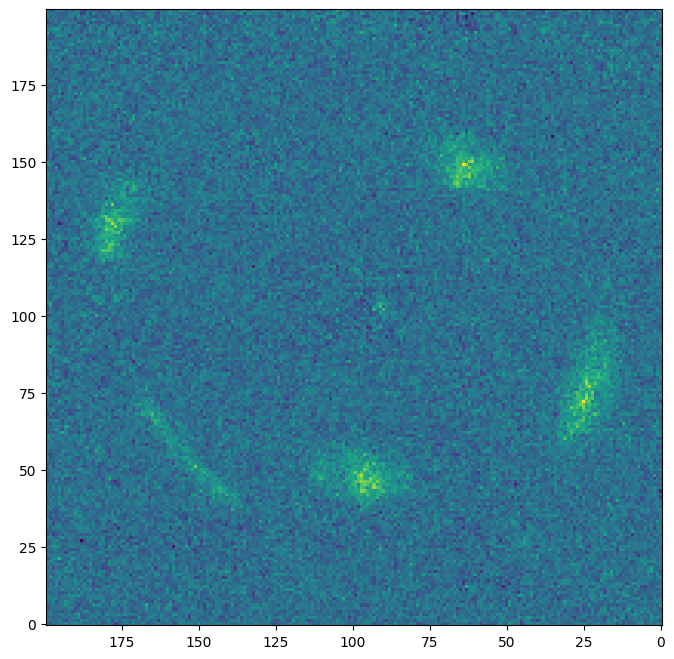

In [5]:
zs = 1.432

spectra_center = 9069
specta_range = 24
gap = 0
spectra_background = 10

buffer = gap + spectra_background
trunc_inds_buff = np.array(
    [
        i
        for i, w in enumerate(wavelengths)
        if w >= spectra_center - (specta_range // 2 + buffer) * delta_wave
        and w <= spectra_center + (specta_range // 2 + buffer) * delta_wave
    ]
)
trunc_wave_buff = wavelengths[trunc_inds_buff]
z_bounds_buffer = (np.min(trunc_inds_buff), np.max(trunc_inds_buff) + 1)

crop_datacube = full_datacube[:, :, z_bounds_buffer[0] : z_bounds_buffer[1]]

imset4 = ImageSet(
    crop_datacube,
    trunc_wave_buff,
    zs,
    pixscale,
    gap,
    spectra_background,
)
imset4.add_aux_info(general_aux_info)
imset4.mask_outliers()

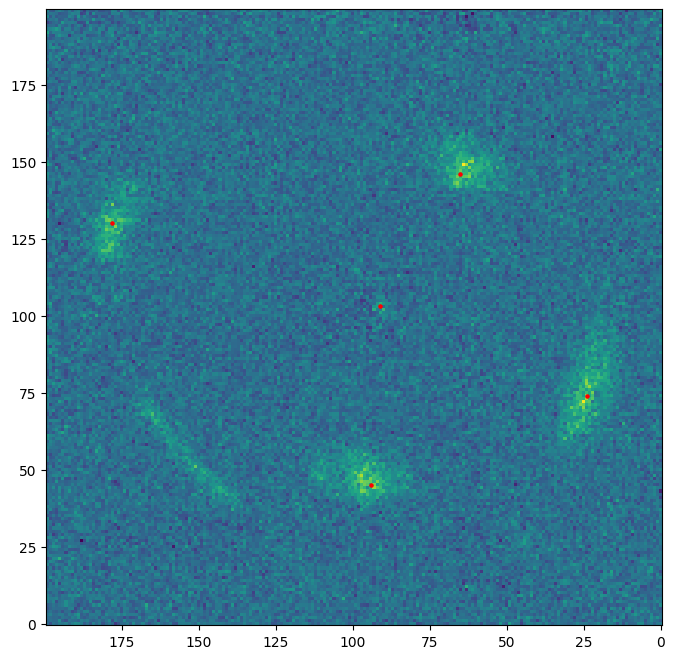

In [6]:
image_locs = np.array([[178, 130], [94, 45], [24, 74], [65, 146], [91, 103]])  
imset4.mark_image_locations(image_locs)

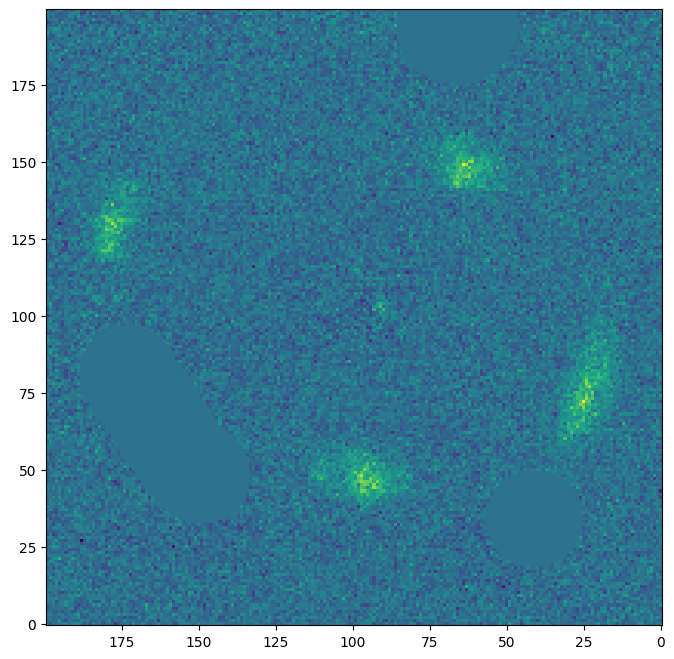

In [7]:
mask_locs = np.array(
    [
        [174, 81, 16],
        [172, 78, 16],
        [170, 75, 16],
        [168, 72, 16],
        [166, 69, 16],
        [164, 66, 16],
        [162, 63, 16],
        [160, 60, 16],
        [158, 57, 16],
        [156, 54, 16],
        [154, 52, 16],
        [152, 50, 16],
        [150, 48, 16],
        [67, 195, 20],
        [42, 34, 16],
    ]
)  
mask_locs = np.array([[j, -(i - size // 2) + size // 2, s] for i, j, s in mask_locs])

img_mask = np.ones(imset4.datacube_whitelight.shape)
for l in mask_locs:
    img_mask *= mask_circle(l[0], l[1], l[2], img_mask.shape)

imset4.set_mask(img_mask)

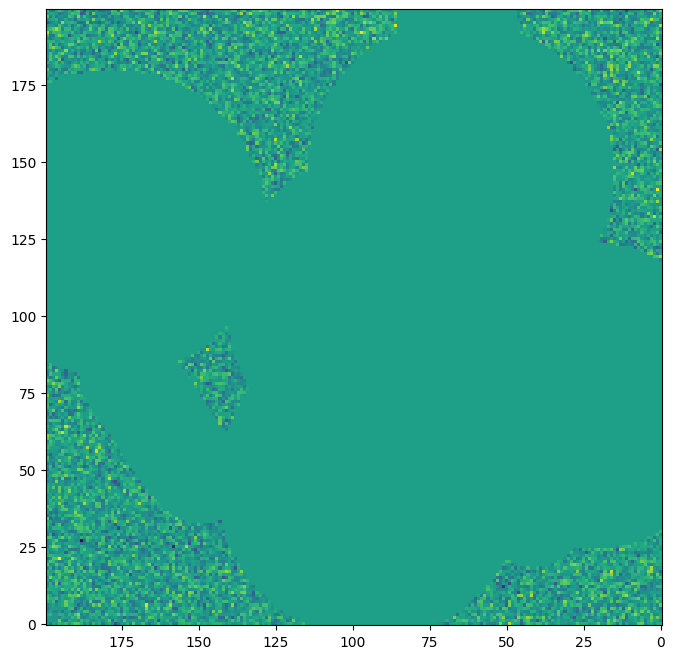

In [8]:
mask_locs = np.array([])

additional_mask = np.ones(imset4.datacube_whitelight.shape)
for l in mask_locs:
    additional_mask *= mask_circle(l[0], l[1], l[2], img_mask.shape)

imset4.noise_level_set(50, additional_mask=additional_mask)

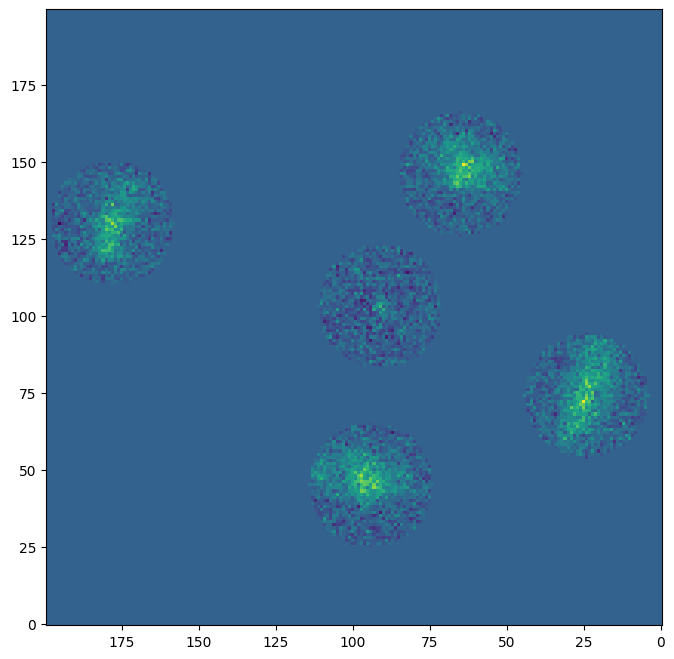

In [9]:
imset4.get_initial_spec_fit_mask(20)

[1.43225239e+00 2.78913526e+00 1.48749203e+04 1.29574809e+00]


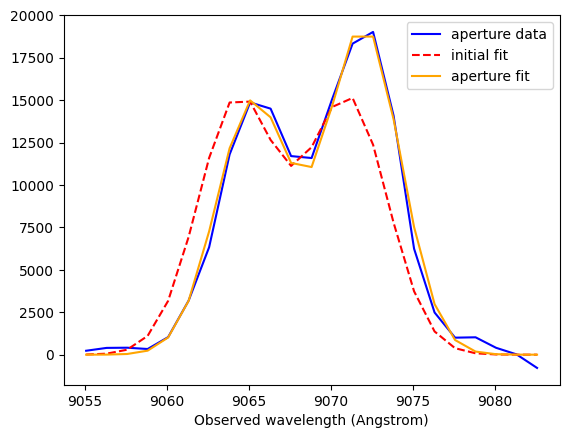

In [10]:
restwave_peaks = [3727.093, 3729.875]
# z, sigma, amp_0, ratios, m, b
init_spec_params = [imset4.zs, 3.0, 15000.0, 1.0]
imset4.get_initial_spec_fit(
    restwave_peaks, init_spec_params, rewrite_zs=False, adjust_slope=False
)

In [11]:
with open("s4_models/imset4.pickle", "wb") as handle:
    pickle.dump(imset4, handle, protocol=pickle.HIGHEST_PROTOCOL)